#Steps

1. Preprocess + EDA + feature Selection
2. Extract input and output cols
3. Scale the values
4. Train test split
5. Train the model
6. Evaluate the model / model selection
7. Deploy the model



In [153]:
import numpy as np
import pandas as pd

In [154]:
df = pd.read_csv("/content/placement.csv")

In [155]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [157]:
df.shape

(100, 4)

In [158]:
#Preprocessing
df = df.iloc[:,1:]

In [159]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [160]:
#EDA
import matplotlib.pyplot as plt

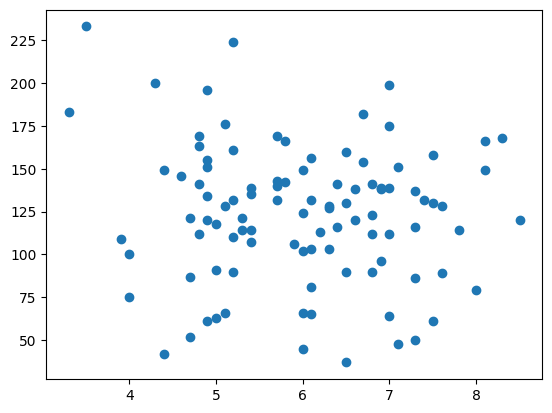

In [161]:
plt.scatter(df['cgpa'],df['iq'])

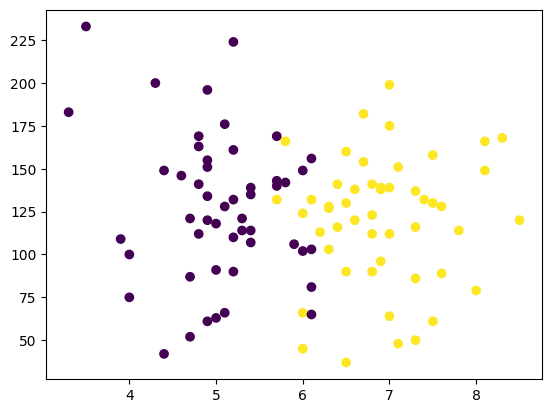

In [162]:
# cgpa on x axis, iq on y axis and colored on that student which are already placed
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [163]:
x = df.iloc[:,0:2]
y = df.iloc[:,2:]

In [164]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [165]:
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


In [166]:
# Train and Test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [167]:
x_train

,cgpa,iq
28,5.2,90.0
12,5.4,139.0
56,6.1,65.0
2,5.3,121.0
34,4.8,163.0
...,...,...
61,7.3,137.0
29,7.0,112.0
70,6.3,127.0
45,6.0,66.0


In [168]:
y_train

,placement
28,0
12,0
56,0
2,0
34,0
...,...
61,1
29,1
70,1
45,1


In [169]:
x_test

,cgpa,iq
81,5.4,107.0
67,5.0,118.0
77,7.3,50.0
53,8.3,168.0
7,5.0,63.0
85,5.8,166.0
22,4.9,120.0
86,5.1,128.0
25,5.0,91.0
24,4.7,121.0


In [170]:
y_test

,placement
81,0
67,0
77,1
53,1
7,0
85,1
22,0
86,0
25,0
24,0


In [171]:
#scaling
from sklearn.preprocessing import StandardScaler

In [172]:
scalar = StandardScaler()

In [173]:
x_train = scalar.fit_transform(x_train)

In [174]:
x_train

array([[-0.73224439, -0.86961575],
       [-0.55556343,  0.35719342],
       [ 0.06281989, -1.4955388 ],
       [-0.64390391, -0.09347118],
       [-1.08560629,  0.95807955],
       [ 0.06281989, -1.09494805],
       [-1.88067057, -0.39391424],
       [-0.73224439,  0.18193497],
       [ 0.23950084,  0.08178728],
       [ 0.23950084, -0.54413577],
       [ 0.7695437 ,  0.3321565 ],
       [-0.73224439,  2.48533178],
       [-1.43896819,  0.60756264],
       [ 0.68120322, -0.86961575],
       [-0.99726581,  0.75778417],
       [-1.26228724,  0.53245187],
       [-0.99726581,  0.23200881],
       [ 0.50452227, -0.1185081 ],
       [-0.99726581,  0.65763648],
       [ 0.32784132,  0.40726726],
       [ 0.15116037, -0.29376655],
       [ 0.4161818 , -2.19657262],
       [ 1.29958655,  0.83289494],
       [ 0.59286275,  1.43378106],
       [ 0.32784132, -0.21865578],
       [ 1.74128893, -1.1450219 ],
       [-2.41071342,  1.45881798],
       [-1.79233009, -1.24516958],
       [ 1.29958655,

In [175]:
x_test = scalar.transform(x_test)

In [176]:
x_test

array([[-0.55556343, -0.44398808],
       [-0.90892534, -0.16858194],
       [ 1.1229056 , -1.87109263],
       [ 2.00631035,  1.08326415],
       [-0.90892534, -1.54561265],
       [-0.20220153,  1.03319031],
       [-0.99726581, -0.1185081 ],
       [-0.82058486,  0.08178728],
       [-0.90892534, -0.84457883],
       [-1.17394676, -0.09347118]])

In [177]:
#Train the model
from sklearn.linear_model import LogisticRegression

In [178]:
clf = LogisticRegression()

In [179]:
clf.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [180]:
#model evaluation
y_pred = clf.predict(x_test)

In [181]:
y_test

,placement
81,0
67,0
77,1
53,1
7,0
85,1
22,0
86,0
25,0
24,0


In [182]:
from sklearn.metrics import accuracy_score

In [183]:
accuracy_score(y_test,y_pred)

0.9

In [184]:
#plot decision boundry
from mlxtend.plotting import plot_decision_regions

<Axes: >

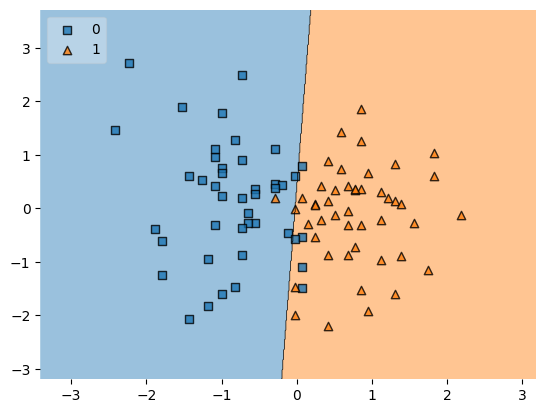

In [188]:
plot_decision_regions(x_train,y_train.values.ravel(),clf=clf,legend=2)

In [189]:
import pickle #Pickle convert object into file which we use in any other environment

In [190]:
pickle.dump(clf,open('model.pkl','wb'))

Server where we deploy the website
1. Amazon web service
2. Google cloud platform
3. Heroku